<a href="https://colab.research.google.com/github/anferivera/Fisica_Computacional_1/blob/main/2_finite_differece_method.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Librery
import numpy as np
import pandas as pd
import time as tm
import matplotlib.pyplot as plt

# 3. Schrodinger equation
$$
H\Psi(\vec{r},t)= i\hbar\dfrac{\partial}{\partial t}\Psi(\vec{r},t)
$$

\begin{equation}
-\dfrac{\hbar^2}{2m}\nabla^2 \Psi(\vec{r},t)+V(\vec{r})\Psi(\vec{r},t)= i\hbar\dfrac{\partial}{\partial t}\Psi(\vec{r},t)
\end{equation}

if $\Psi(\vec{r},t)=e^{-i E t/\hbar}\,\psi(\vec{r})$ we get:

$$\boxed{
-\dfrac{\hbar^2}{2m}\nabla^2 \psi(\vec{r}) + U(\vec{r})\psi(\vec{r})= E\,\psi(\vec{r})}$$

## 3.1: Infinite potential energy well

First let’s examine the solutions to the Schrödinger equation for the special
case of a constant potential energy, equal to 

\begin{align}
U(x) = & 0,\,\,\, 0 \leq x\leq L\\
     = & \infty,\,\,  0 < x, x > L
\end{align}


see: *Moder Physics, Kenneth S. Krane* 

<img src="https://github.com/anferivera/Fisica_Computacional_1/blob/main/Sesiones/PDE/figures/well1.png?raw=true" alt="Texto alternativo" width="300" height="300">

The solution in given by:

$$\psi_n(x)=\sqrt{\dfrac{2}{L}}\sin(\dfrac{n\pi x}{L})$$

$$\boxed{E_n=\dfrac{\hbar^2\pi^2n^2}{2mL^2}}$$

$n=1,2,3...$



In [2]:
# Wave function of the particle in a box
def psi1(n,L,x):
    return np.sqrt(2/L)*np.sin(n*np.pi*x/L)

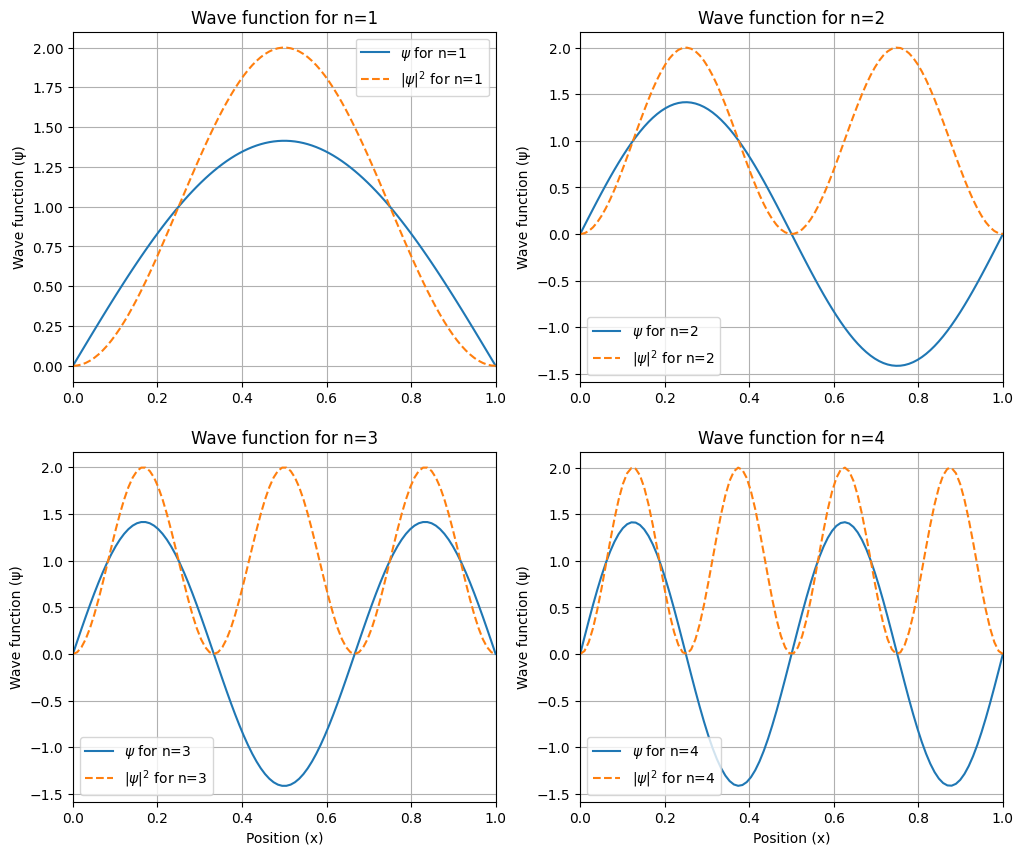

In [3]:
L = 1.0 # Length of the box
x = np.linspace(0, L, 100) # Position array

fig, ax = plt.subplots(2, 2, figsize=(12, 10))

ax[0, 0].plot(x, psi1(1, L, x), label=r'$\psi$ for n=1')
ax[0, 0].plot(x, psi1(1, L, x)**2,linestyle='--', label=r'$|\psi|^2$ for n=1')
ax[0, 0].set_title('Wave function for n=1')
#ax[0, 0].set_xlabel('Position (x)')
ax[0, 0].set_ylabel('Wave function (ψ)')
ax[0, 0].legend()
ax[0, 0].set_xlim(0, L)
ax[0, 0].grid()

ax[0, 1].plot(x, psi1(2, L, x), label=r'$\psi$ for n=2')
ax[0, 1].plot(x, psi1(2, L, x)**2,linestyle='--', label=r'$|\psi|^2$ for n=2')
ax[0, 1].set_title('Wave function for n=2')
#ax[0, 1].set_xlabel('Position (x)')
ax[0, 1].set_ylabel('Wave function (ψ)')
ax[0, 1].legend()
ax[0, 1].set_xlim(0, L)
ax[0, 1].grid()

ax[1, 0].plot(x, psi1(3, L, x), label=r'$\psi$ for n=3')
ax[1, 0].plot(x, psi1(3, L, x)**2,linestyle='--', label=r'$|\psi|^2$ for n=3')
ax[1, 0].set_title('Wave function for n=3')
ax[1, 0].set_xlabel('Position (x)')
ax[1, 0].set_ylabel('Wave function (ψ)')
ax[1, 0].legend()
ax[1, 0].set_xlim(0, L)
ax[1, 0].grid()

ax[1, 1].plot(x, psi1(4, L, x), label=r'$\psi$ for n=4')
ax[1, 1].plot(x, psi1(4, L, x)**2,linestyle='--', label=r'$|\psi|^2$ for n=4')
ax[1, 1].set_title('Wave function for n=4')
ax[1, 1].set_xlabel('Position (x)')
ax[1, 1].set_ylabel('Wave function (ψ)')
ax[1, 1].legend()
ax[1, 1].set_xlim(0, L)
ax[1, 1].grid()

## 3.2: finite potential energy well

First let’s examine the solutions to the Schrödinger equation for the special
case of a constant potential energy, equal to 

\begin{align}
U(x) = & 0,\,\,\, 0 \leq x\leq L\\
U(x) = & U_0,\,\,  0 < x, x > L
\end{align}


see: *Moder Physics, Kenneth S. Krane* 

<img src="https://github.com/anferivera/Fisica_Computacional_1/blob/main/Sesiones/PDE/figures/well2.png?raw=true" alt="Texto alternativo" width="300" height="300">


The solution to the Schrodinger equation $-\dfrac{\hbar^2}{2m}\nabla^2 \psi(x) + U(x)\psi(x)= E\,\psi(x)$ in given by:

$\psi(x)=A\sin(kx)+B\cos(kx)$ for $0\leq x\leq L$.

$\psi(x)=Ce^{\alpha x}$ for $x < 0$.

$\psi(x)=Ge^{-\alpha x}$ for $x > L$.

Using the boundary conditions (continuity and normalization). the resulting solution for the energy
values cannot be obtained in terms of a direct equation, but
instead must be found numerically by solving a transcendental equation. The
result is a series of increasing energy values, but the number of energy values
is finite rather than infinite, because the energy cannot be allowed to exceed
the value of $U_0$.

The solutions may be of either odd or even parity with respect to the center of the well. The Schrodinger equation gives `trancendental` forms for both, so that `numerical solution methods` must be used.

### **Even Solution, Finite Box**


\begin{align}
  \psi_1(x) = & B\cos(kx)\,, 0\leq x\leq L\\
  \psi_2(x) = & Ce^{\alpha x}\,, x < 0\\
  \psi_3(x) = & Ce^{-\alpha x}\,, x > L
\end{align}

Continuity:

\begin{equation}
C = \dfrac{B\cos(kL/2)}{e^{-\alpha L/2}}
\end{equation}

Normalization (it give us B. do it):
\begin{equation}
\int_{-L/2}^{L/2}|\Psi|^2 dx = 1
\end{equation}

http://hyperphysics.phy-astr.gsu.edu/hbase/quantum/pfbox.html#c2

with $-L/2 <x <L/2$

$$\alpha = k\tan\big(\dfrac{kL}{2}\big)= \sqrt{\dfrac{2m(U_0-E)}{\hbar^2}}=\sqrt{\beta^2-k^2}$$

$$\beta^2 = \dfrac{2mU_o}{\hbar^2}\,, E=\dfrac{\hbar^2k^2}{2m} $$

The ground state solution for a finite potential well is the lowest even parity state. Since both sides of the equation are dependent on the energy $E$ for which you are solving, the equation is trancendental and must be solved numerically. Once we get $k_i$ you get $\alpha_i$ and $E_i$. See the next plot

**Example**:

Let's consider a particle in a box. With the parametrization $v=kL/2$. The solution is writes as

$$v\tan(v)=\sqrt{u_0^2-v^2}$$

with $u_0=\dfrac{\beta L}{2}=\dfrac{L}{2}\sqrt{\dfrac{2mU_0}{\hbar^2}}$.  Let's consider the example with $u_0^2=20$.

In [4]:
def ki(vi,L):
    return 2*vi/L

def alphai(ki,L):
    return ki*np.tan(ki*L/2)

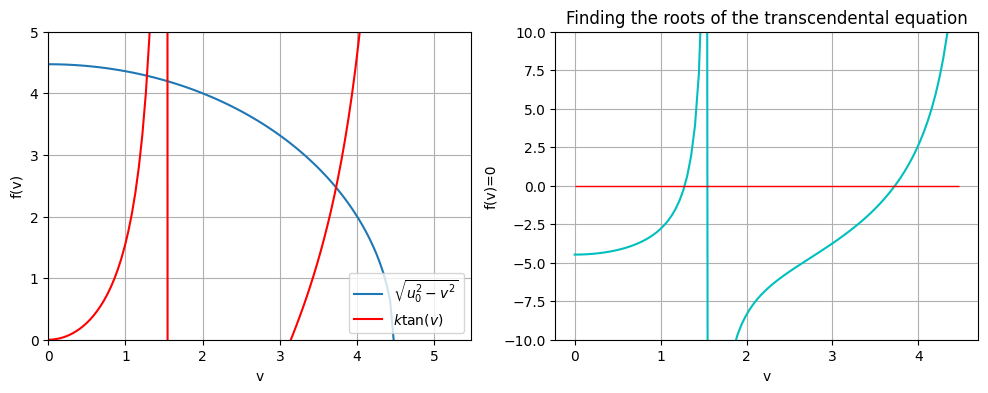

In [6]:
# Example with transcendental equation
fig, ax= plt.subplots(1,2, figsize=(12, 4))

u0 = np.sqrt(20)
v= np.linspace(0, u0, 100)
ax[0].plot(v, np.sqrt(u0**2-v**2),label=r'$\sqrt{u_0^2-v^2}$') 
ax[0].plot(v, v*np.tan(v),'r-',label=r'$k\tan(v)$')
ax[0].set_xlabel('v')
ax[0].set_ylabel('f(v)')
ax[0].grid(True)
ax[0].set_xlim(0, v.max()+1)
ax[0].set_ylim(0, 5)
ax[0].legend()

# To see the roots of the transcendental equation, we can plot the function f(v) 
def f(v):
    return v*np.tan(v) - np.sqrt(u0**2 - v**2)
#
ax[1].plot(v, f(v),'c-')
ax[1].hlines(0, 0, u0, color='red', lw=1)
ax[1].set_title('Finding the roots of the transcendental equation')
ax[1].set_xlabel('v')
ax[1].set_ylabel('f(v)=0')
ax[1].grid(True)
ax[1].set_ylim(-10, 10)
plt.show()

In [7]:
import scipy.optimize as optimize

def f(v):
    return v*np.tan(v) - np.sqrt(u0**2 - v**2)

# ******* roots with secant method
#print("root:", optimize.newton(f,1,fprime=None, tol=1e-06))
#print('\n')
# ******* roots with bisection method
v1 = optimize.bisect(f, 1, 1.5, xtol=1e-6)
v2 = optimize.bisect(f, 1.29, 1.6, xtol=1e-6)
v3 = optimize.bisect(f, 3.5, 4, xtol=1e-6)
print("Roots of the transcendental equation are:")
print("root_1:", v1)
print("root_2:", v2)
print("root_3:", v3)

Roots of the transcendental equation are:
root_1: 1.280421257019043
root_2: 1.5707961845397949
root_3: 3.7271337509155273


In this case we hace three roots, which correspond to the three bound states of the particle 
in the finite potential well. The roots can be used to calculate the energy levels.

$E_{v_i} = \dfrac{\hbar^2}{2m}k^2=\dfrac{\hbar^2}{2m}\bigg(\dfrac{2v_i}{L}\bigg)^2$

In [12]:
def B(L,k,alpha,x0):
    a = (L-(1/2*k)*np.sin(2*k*L))
    b = (1/alpha)*(np.cos(k*L/2))**2
    c = np.exp(-2*alpha*x0)-1
    k = a-b*c
    return np.sqrt(np.abs(1/k))

def C(B,k,L,alpha):
    x = np.exp(-alpha*L/2)
    if x == 0.:
        return 0
    else:
        return B*np.cos(k*L/2)/np.exp(-alpha*L/2) 

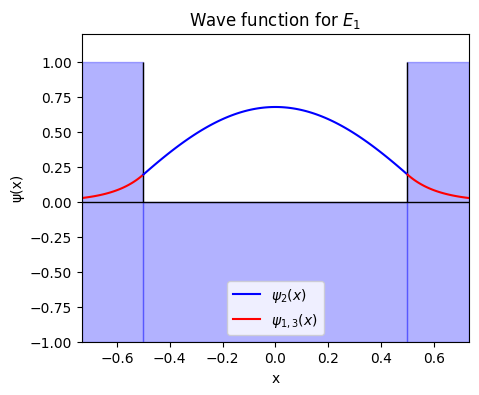

In [13]:
# values
L = 1.0 # Length of the box
## Root 1 and parameters
v = v1
k = ki(v,L)
alpha = alphai(k,L)
x0 = 2/alpha
# for ploting the wave function, we need to define the x values for each region of the potential well
x1 = np.linspace(-x0-L/2, -L/2,100) 
x2 = np.linspace(-L/2, L/2, 100)
x3 = np.linspace(+L/2, L/2+x0,100) 

### well
plt.figure(figsize=(5, 4))
plt.vlines(-L/2, 0, 1, color='black', lw=1)
plt.vlines(+L/2, 0, 1, color='black', lw=1)
plt.hlines(0, -x0-L/2, L/2+x0, color='black', lw=1)
plt.fill_between(x1, -1, 1, color='blue', alpha=0.3)
plt.fill_between(x2, -1, 0, color='blue', alpha=0.3)
plt.fill_between(x3, -1, 1, color='blue', alpha=0.3)

#Plot the wave functions corresponding to the roots found
B1 = B(L, k, alpha, x0)
C1 = C(B1, k, L, alpha)

plt.plot(x1, C1*np.exp(+alpha*x1),'r-')
plt.plot(x2, B1*np.cos(k*x2),'b-',label=r'$\psi_2(x)$')
plt.plot(x3, C1*np.exp(-alpha*x3),'r-',label=r'$\psi_{1,3}(x)$')
plt.title(r'Wave function for $E_1$')
plt.xlabel('x')
plt.ylabel('ψ(x)')
plt.xlim(-x0-L/2, L/2+x0)
plt.ylim(-1, 1.2)
plt.legend()
plt.show()

In [14]:
print("k1:", k)
print("alpha1:", alpha)
print("B1:", B1)
print("C1:", C1)
print("x0:", x0)

k1: 2.560842514038086
alpha1: 8.56981244591327
B1: 0.6766571645506692
C1: 14.064321217748539
x0: 0.23337733615789344


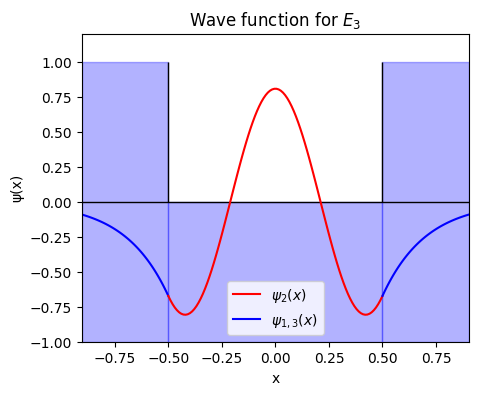

In [15]:
# values
L = 1.0 # Length of the box
## Root 3 and parameters
v = v3
k = ki(v,L)
alpha = alphai(k,L)
x0 = 2/alpha
# for ploting the wave function, we need to define the x values for each region of the potential well
x1 = np.linspace(-x0-L/2, -L/2,100) 
x2 = np.linspace(-L/2, L/2, 100)
x3 = np.linspace(+L/2, L/2+x0,100) 

### well
plt.figure(figsize=(5, 4))
plt.vlines(-L/2, 0, 1, color='black', lw=1)
plt.vlines(+L/2, 0, 1, color='black', lw=1)
plt.hlines(0, -x0-L/2, L/2+x0, color='black', lw=1)
plt.fill_between(x1, -1, 1, color='blue', alpha=0.3)
plt.fill_between(x2, -1, 0, color='blue', alpha=0.3)
plt.fill_between(x3, -1, 1, color='blue', alpha=0.3)

#Plot the wave functions corresponding to the roots found
B1 = B(L, k, alpha, x0)
C1 = C(B1, k, L, alpha)

plt.plot(x1, C1*np.exp(+alpha*x1),'b-')
plt.plot(x2, B1*np.cos(k*x2),'r-',label=r'$\psi_2(x)$')
plt.plot(x3, C1*np.exp(-alpha*x3),'b-',label=r'$\psi_{1,3}(x)$')
plt.title(r'Wave function for $E_3$')
plt.xlabel('x')
plt.ylabel('ψ(x)')
plt.xlim(-x0-L/2, L/2+x0)
plt.ylim(-1, 1.2)
plt.legend()
plt.show()

### Laboratory: 

**Exercise 1** Construc the the wave function for $E_2$ in the last example.

**Exercise 2**: (Real case, real values) The energy levels for an electron in a potential well of depth $U_0=64$ eV and width $L=0.39$ nm. Find the energy levels and plot the wave functions.

In [ ]:
#************ Numerical values MKS ************
'''
m = 9.10938356e-31 # Mass of the particle in kg
h = 6.62607015e-34 # Planck's constant in J*s
eV = 1.602176634e-19 # Joules
U = 64*eV # Potential energy in Joules
L = 0.39e-9 # Length of the box in meters
hbar = h/(2*np.pi)
'''
#*********** Natural units *******************
m = 0.511e6 # Mass of the particle in eV/c^2
hbar = 1
eV = 1.602176634E-19 # Joules
U = 64*eV # Potential energy in Joules
L = 0.39e-9*5.0675e15 # Length in GeV-1
#*********************************************
#print(m,hbar,eV,U,L)

def beta(U0):
    return np.sqrt(2*m*U0)/hbar

def E(k):
    return (hbar**2 * k**2)/(2*m)

def f(k):
    return k*np.tan(k*L/2) - np.sqrt(beta(U)**2 - k**2)

## 3.3 Quantum tunneling

In physics, quantum tunnelling, barrier penetration, or simply tunnelling is a quantum mechanical phenomenon in which an object such as an electron or atom passes through a potential energy barrier that, according to classical mechanics, should not be passable due to the object not having sufficient energy to pass or surmount the barrier...

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/4/41/TunnelEffektKling1.svg/1920px-TunnelEffektKling1.svg.png?utm_source=en.wikipedia.org&utm_campaign=imageinfo&utm_content=thumbnail" alt="Texto alternativo" width="500" height="300">

Wiki: A simulation of a wave packet incident on a potential barrier. In relative units, the barrier energy is 20, greater than the mean wave packet energy of 14. A portion of the wave packet passes through the barrier.

![tunneling](https://upload.wikimedia.org/wikipedia/commons/4/48/E14-V20-B1.gif?utm_source=commons.wikimedia.org&utm_campaign=index&utm_content=original)

## 3.4 Numerical solution of the Schrodinger equation using FDM 

## 3. Schrodinger equation by FDM

\begin{equation}
\boxed{
\nabla^2 u(x,y,t)= \dfrac{\partial^2 u(x,y,t)}{\partial x^2} +\dfrac{\partial^2 u(x,y,t)}{\partial y^2}= \dfrac{1}{\alpha}\dfrac{\partial u(x,y,t)}{\partial t}}\,,
\end{equation}

where $1/\alpha$ is the diffusion coefficient. Here, we will express derivatives in terms of finite differences in the values of $u$ at the laticce sites. For space coordinates in 2D:


\begin{align}
\dfrac{\partial^2 u(x,y)}{\partial x^2}+\dfrac{\partial^2 u(x,y)}{\partial y^2} &\approx \dfrac{u(x+\Delta x,y)+u(x-\Delta x,y)-2u(x,y)}{(\Delta x)^2}\nonumber\\ & +  \dfrac{u(x, y+\Delta y)+u(x,y-\Delta y)-2u(x,y)}{(\Delta y)^2} \,.
\end{align}

For time:
* Derivate to the right:
\begin{align}
u(x,y,t+\Delta t) = u(x,y,t) + \dfrac{\partial u}{\partial t}\Delta t + \dfrac{1\partial^2 u}{2\partial t^2}(\Delta t)^2 + \cdots
\end{align}
* Derivate to the left:
\begin{align}
u(x,y,t-\Delta t) = u(x,y,t) - \dfrac{\partial u}{\partial t}\Delta t + \dfrac{1\partial^2 u}{2\partial t^2}(\Delta t)^2 + \cdots\,,
\end{align}
* Central derivative:
\begin{align}
\dfrac{\partial u}{\partial t} \approx \dfrac{u(x,y,t+\Delta t) -u(x,y,t-\Delta t)}{2\Delta t} \,.
\end{align}

Let's suppose $\Delta x=\Delta y$, $x_i=x_0+i\Delta$, $y_j=y_0+j\Delta$, $t_k=k\Delta t$, $\{i,j,k\}=0,\cdots N$. Using the derivative to the right (forward in time), the Diffusion's equation can be writeen as:

\begin{align}
\dfrac{\big[ u_{i+1,j,k}+u_{i-i,j,k} +
u_{i,j+1,k}+u_{i,j-1,k} -4u_{i,j,k} \big]}{\Delta^2}
= \dfrac{1}{\alpha}\dfrac{\big(u_{i,j,k+1}-u_{i,j,k}\big)}{\Delta t}\,,
\end{align}
and the state of the system at time step $k+1$ may be calculated from its state at time step $k$ as:

\begin{align}
\boxed{
u_{i,j,k+1}=u_{i,j,k}+\alpha\Delta t\,\dfrac{\big[ u_{i+1,j,k}+u_{i-i,j,k} +
u_{i,j+1,k}+u_{i,j-1,k} -4u_{i,j,k} \big]}{\Delta^2}} \,.
\end{align}

